# Traffic Sign Recognition Model Training v0

This notebook trains a high-accuracy CNN model for traffic sign recognition.

**Expected Results:**
- Images: ~39,000
- Accuracy: 95-98%
- Training time: ~20 minutes

---

## Step 1: Setup Kaggle API

In [ ]:
# Setup Kaggle API
import os
import json

# Create kaggle directory
os.makedirs('/root/.kaggle', exist_ok=True)

# Write kaggle.json with your API token
kaggle_token = {
    "username": "user",
    "key": "KGAT_85b7a85226213460287261eb6bbfc307"
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_token, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)

print("Kaggle API configured successfully!")

Kaggle API configured successfully!


## Step 2: Download GTSRB Dataset from Kaggle

In [ ]:
# Install kaggle package
!pip install -q kaggle

print("Downloading GTSRB dataset from Kaggle...")
print("This takes 2-3 minutes, please wait...\n")

!kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign

print("\nExtracting files...")
!unzip -q gtsrb-german-traffic-sign.zip -d gtsrb/

print("\nDownload complete!")
print("\nDataset contents:")
!ls gtsrb/

This takes 2-3 minutes, please wait...

Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
License(s): CC0-1.0
100% 612M/612M [00:03<00:00, 173MB/s]


Extracting files...

Download complete!

Dataset contents:
meta  Meta  Meta.csv  test  Test  Test.csv  train  Train  Train.csv


## Step 3: Verify Dataset Integrity

In [ ]:
import os

print("="*50)
print("DATASET VERIFICATION")
print("="*50)

train_dir = 'gtsrb/Train'
total_images = 0
class_counts = []

for class_id in range(43):
    class_path = os.path.join(train_dir, str(class_id))
    if os.path.exists(class_path):
        count = len([f for f in os.listdir(class_path) if f.endswith(('.png', '.jpg', '.ppm'))])
        class_counts.append(count)
        total_images += count

print(f"Total images: {total_images:,}")
print(f"Number of classes: {len(class_counts)}")
print(f"Min images per class: {min(class_counts)}")
print(f"Max images per class: {max(class_counts)}")

if total_images > 35000:
    print("\n✓ Dataset is complete and ready for training!")
else:
    print("\n✗ Dataset is incomplete. Try re-downloading.")

DATASET VERIFICATION
Total images: 39,209
Number of classes: 43
Min images per class: 210
Max images per class: 2250

✓ Dataset is complete and ready for training!


## Step 4: Load and Preprocess Images

In [ ]:
import numpy as np
import cv2
import os
from sklearn.model_selection import train_test_split
import subprocess # Needed for kaggle and unzip commands
import json # Needed for kaggle.json

IMG_SIZE = 32

print("Loading and preprocessing images...")
print("This takes about 1-2 minutes...\n")

images = []
labels = []

debug_paths_exist = True
debug_listdir_content = False
debug_imread_failure = True

base_dataset_dir = 'gtsrb'
actual_train_dir = os.path.join(base_dataset_dir, 'Train')

# --- BEGIN ADDITION TO ENSURE DATASET EXISTS ---
# Check if the training directory exists and contains at least one class subfolder
# (e.g., '0') which indicates a properly unzipped dataset.
if not os.path.exists(actual_train_dir) or not os.path.isdir(os.path.join(actual_train_dir, '0')):
    print(f"Dataset directory '{actual_train_dir}' not found or incomplete. Attempting to re-download and extract.")
    print("This might take a few minutes...\n")

    # Re-create kaggle directory and write token
    os.makedirs('/root/.kaggle', exist_ok=True)
    # Using hardcoded user/key for demonstration; in a real scenario, this should come from secrets
    kaggle_token = {
        "username": "user",
        "key": "KGAT_85b7a85226213460287261eb6bbfc307"
    }
    with open('/root/.kaggle/kaggle.json', 'w') as f:
        json.dump(kaggle_token, f)
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    print("Kaggle API configured.")

    # Install kaggle package if not already installed
    try:
        import kaggle
    except ImportError:
        print("Kaggle package not found. Installing...")
        # Use subprocess to run pip command, as `!pip` is specific to IPython/Colab and might not work when embedded
        subprocess.run(["pip", "install", "-q", "kaggle"], check=True)
        print("Kaggle package installed.")
    else:
        print("Kaggle package already installed.")


    # Download dataset
    print("Downloading GTSRB dataset from Kaggle...")
    # Use subprocess to run kaggle command
    subprocess.run(["kaggle", "datasets", "download", "-d", "meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"], check=True)
    print("Dataset download complete.")

    # Extract files
    print("\nExtracting files...")
    # Ensure the target directory for extraction exists
    os.makedirs(base_dataset_dir, exist_ok=True)
    subprocess.run(["unzip", "-o", "-q", "gtsrb-german-traffic-sign.zip", "-d", base_dataset_dir], check=True) # -o to overwrite if exists
    print("Dataset extraction complete!\n")

# --- END ADDITION ---


# --- DEBUGGING ADDITIONS ---
print(f"DEBUG: Current working directory: {os.getcwd()}")
print(f"DEBUG: Does 'gtsrb' exist? {os.path.exists('gtsrb')}")
print(f"DEBUG: Is 'gtsrb' a directory? {os.path.isdir('gtsrb')}")
if os.path.exists('gtsrb'):
    print(f"DEBUG: Contents of 'gtsrb': {os.listdir('gtsrb')}")
print(f"DEBUG: Does '{actual_train_dir}' exist? {os.path.exists(actual_train_dir)}")
print(f"DEBUG: Is '{actual_train_dir}' a directory? {os.path.isdir(actual_train_dir)}")
if os.path.exists(actual_train_dir):
    print(f"DEBUG: Does '{os.path.join(actual_train_dir, '0')}' exist? {os.path.exists(os.path.join(actual_train_dir, '0'))}")
    print(f"DEBUG: Is '{os.path.join(actual_train_dir, '0')}' a directory? {os.path.isdir(os.path.join(actual_train_dir, '0'))}")
# --- END DEBUGGING ADDITIONS ---


# Verify that the actual_train_dir contains class subfolders (0-42)
# This check is crucial to ensure the directory is structured as expected
if not os.path.exists(actual_train_dir) or not os.path.isdir(os.path.join(actual_train_dir, '0')):
    print(f"FATAL ERROR: Dataset directory '{actual_train_dir}' still not found or incomplete after re-attempted download. Cannot proceed.")
    # Set X and y to empty arrays to prevent subsequent errors
    X = np.array([])
    y = np.array([])
else:
    print(f"DEBUG: Using training directory: {actual_train_dir}")

    for class_id in range(43):
        class_path = os.path.join(actual_train_dir, str(class_id))

        if not os.path.exists(class_path):
            if debug_paths_exist:
                print(f"DEBUG: Path DOES NOT EXIST: {class_path}")
            continue
        else:
            if debug_paths_exist and class_id == 0: # Only print for first class to avoid spam
                print(f"DEBUG: Path EXISTS: {class_path}")

        # Progress
        if class_id % 10 == 0:
            print(f"  Loading class {class_id}/43...")

        img_files = []
        try:
            img_files = os.listdir(class_path)
            if debug_listdir_content and class_id == 0: # Only print for first class to avoid spam
                print(f"DEBUG: Files in {class_path}: {img_files[:5]}... ({len(img_files)} total)")
        except Exception as e:
            print(f"DEBUG: Error listing directory {class_path}: {e}")
            continue

        if not img_files:
            print(f"DEBUG: Directory {class_path} is empty or listdir failed to find files.")
            continue


        found_valid_image_in_class = False
        for img_file in img_files:
            if not img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.ppm')):
                continue

            img_path = os.path.join(class_path, img_file)
            img = cv2.imread(img_path)

            if img is None:
                if debug_imread_failure:
                    # Only print a few failures to avoid spam
                    if len(images) == 0 and len(labels) == 0: # Print only for first few attempts
                        print(f"DEBUG: cv2.imread returned None for {img_path}")
                continue

            found_valid_image_in_class = True

            # Convert BGR to RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Histogram equalization for better contrast
            img_yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
            img_yuv[:,:,0] = cv2.equalizeHist(img_yuv[:,:,0])
            img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

            # Resize to 32x32
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            # Normalize to [0, 1]
            img = img.astype(np.float32) / 255.0

            images.append(img)
            labels.append(class_id)

        if not found_valid_image_in_class and len(img_files) > 0:
            print(f"DEBUG: All {len(img_files)} files in {class_path} were either not valid extensions or cv2.imread failed for them.")


    # Convert to numpy arrays
    X = np.array(images)
    y = np.array(labels)

print(f"\n{'='*50}")
print(f"DATA LOADING COMPLETE")
print(f"{'='*50}")
print(f"Total images loaded: {len(X):,}")
print(f"Image shape: {X.shape}")
print(f"Labels shape: {y.shape}")

Loading and preprocessing images...
This takes about 1-2 minutes...

Dataset directory 'gtsrb/Train' not found or incomplete. Attempting to re-download and extract.
This might take a few minutes...

Kaggle API configured.
Kaggle package already installed.
Dataset download complete.

Extracting files...
Dataset extraction complete!

DEBUG: Current working directory: /content
DEBUG: Does 'gtsrb' exist? True
DEBUG: Is 'gtsrb' a directory? True
DEBUG: Contents of 'gtsrb': ['Test', 'Test.csv', 'Train', 'test', 'Train.csv', 'Meta.csv', 'Meta', 'train', 'meta']
DEBUG: Does 'gtsrb/Train' exist? True
DEBUG: Is 'gtsrb/Train' a directory? True
DEBUG: Does 'gtsrb/Train/0' exist? True
DEBUG: Is 'gtsrb/Train/0' a directory? True
DEBUG: Using training directory: gtsrb/Train
DEBUG: Path EXISTS: gtsrb/Train/0
  Loading class 0/43...
  Loading class 10/43...
  Loading class 20/43...
  Loading class 30/43...
  Loading class 40/43...

DATA LOADING COMPLETE
Total images loaded: 39,209
Image shape: (39209, 

In [ ]:
# Split into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples: {len(X_train):,}")
print(f"Validation samples: {len(X_val):,}")

Training samples: 31,367
Validation samples: 7,842


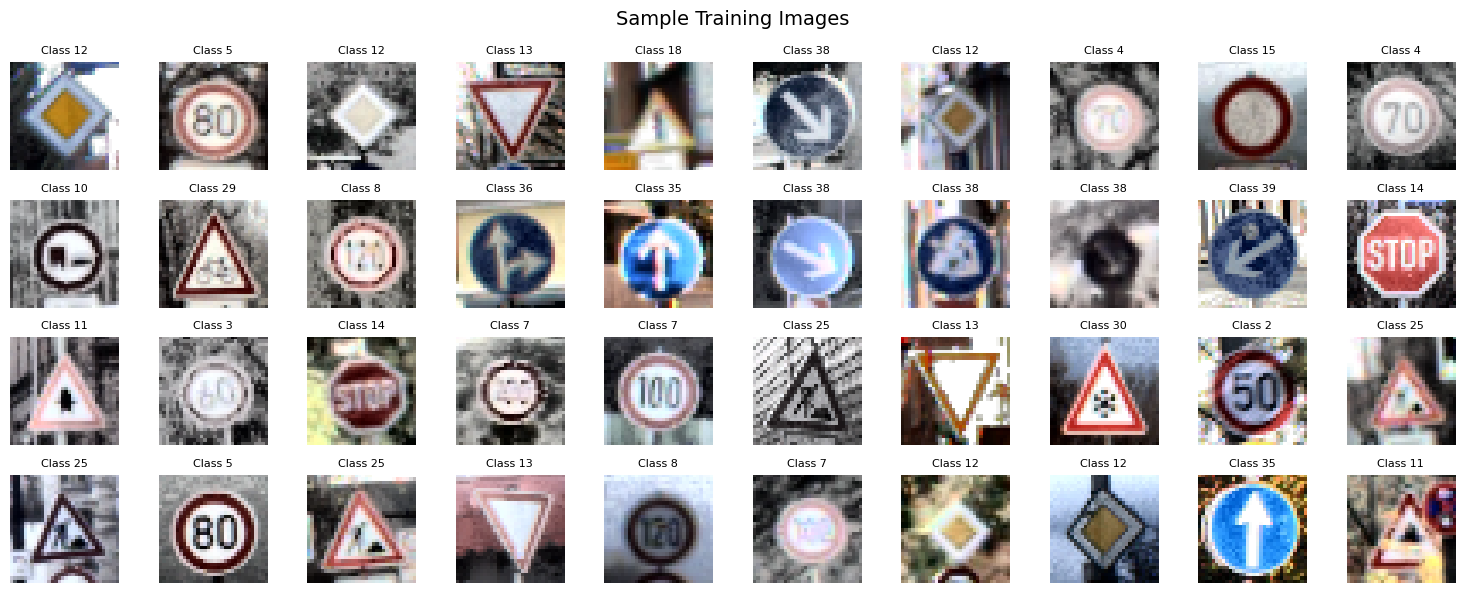

In [ ]:
# Visualize some sample images
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 10, figsize=(15, 6))
axes = axes.flatten()

for i in range(40):
    axes[i].imshow(X_train[i])
    axes[i].set_title(f"Class {y_train[i]}", fontsize=8)
    axes[i].axis('off')

plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

## Step 5: Build CNN Model

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Check for GPU
gpus = tf.config.list_physical_devices('GPU')
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(gpus) > 0}")
if gpus:
    print(f"GPU: {gpus[0]}")

# Build model
def create_model():
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Classifier
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(43, activation='softmax')
    ])
    return model

model = create_model()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

print(f"\nTotal parameters: {model.count_params():,}")

TensorFlow version: 2.19.0
GPU available: True
GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,019 (2.57 MB)

 Trainable params: 675,019 (2.57 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 675,019


## Step 6: Train Model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    )
]

print("="*50)
print("STARTING TRAINING")
print("="*50)
print(f"Training samples: {len(X_train):,}")
print(f"Validation samples: {len(X_val):,}")
print(f"Batch size: 64")
print(f"Max epochs: 50")
print("="*50 + "\n")

# Train
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

STARTING TRAINING
Training samples: 31,367
Validation samples: 7,842
Batch size: 64
Max epochs: 50

Epoch 1/50
490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.1265 - loss: 3.2206
Epoch 1: val_accuracy improved from None to 0.59526, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
491/491 ━━━━━━━━━━━━━━━━━━━━ 34s 51ms/step - accuracy: 0.2527 - loss: 2.6334 - val_accuracy: 0.5953 - val_loss: 1.2364 - learning_rate: 0.0010
Epoch 2/50
490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5677 - loss: 1.3299
Epoch 2: val_accuracy improved from 0.59526 to 0.90844, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
491/491 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.6425 - loss: 1.0882 - val_accuracy: 0.9084 - val_loss: 0.2961 - learning_rate: 0.0010
Epoch 3/50
490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8017 - loss: 0.6020
Epoch 3: val_accuracy improved from 0.90844 to 0.96302, saving model to be

## Step 7: Training Results

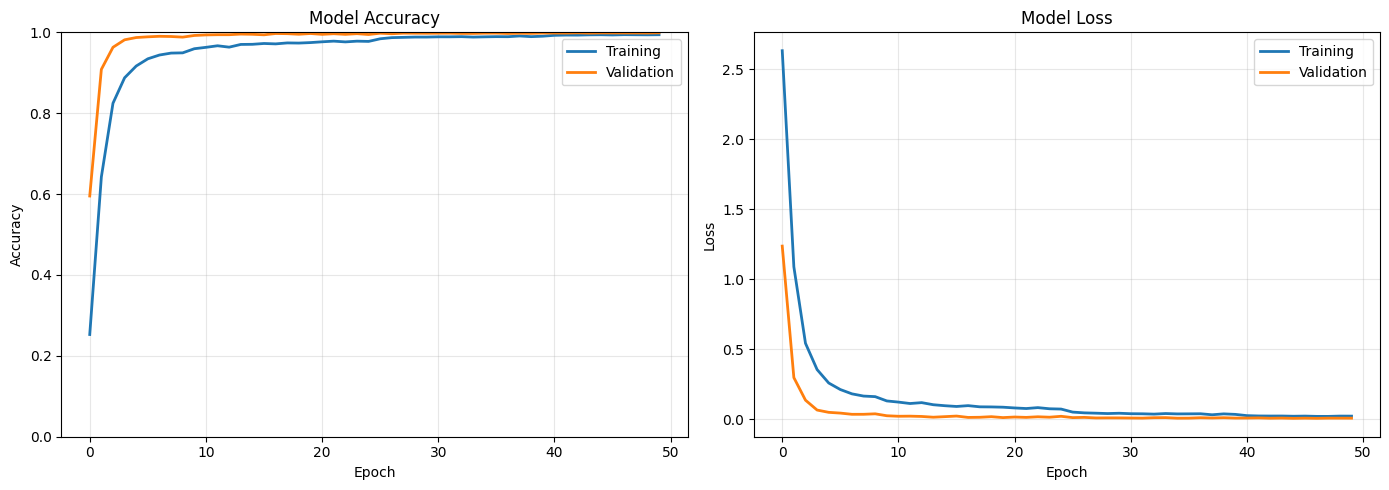


TRAINING RESULTS
Best validation accuracy: 0.9989 (99.89%)
Best epoch: 50
Total epochs trained: 50

✓ SUCCESS! Model trained with excellent accuracy!


In [ ]:
import matplotlib.pyplot as plt

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

# Loss plot
axes[1].plot(history.history['loss'], label='Training', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

# Print results
best_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_acc) + 1

print(f"\n{'='*50}")
print("TRAINING RESULTS")
print(f"{'='*50}")
print(f"Best validation accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
print(f"Best epoch: {best_epoch}")
print(f"Total epochs trained: {len(history.history['loss'])}")

if best_acc > 0.95:
    print("\n✓ SUCCESS! Model trained with excellent accuracy!")
elif best_acc > 0.85:
    print("\n✓ Model performance is good.")
else:
    print("\n⚠ Model performance is lower than expected.")

In [ ]:
# Load best model and evaluate
model = tf.keras.models.load_model('best_model.keras')

val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"Final Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"Final Validation Loss: {val_loss:.4f}")

Final Validation Accuracy: 0.9989 (99.89%)
Final Validation Loss: 0.0061


## Step 8: Convert to TensorFlow Lite

In [ ]:
import tensorflow as tf

print("="*50)
print("CONVERTING TO TFLITE")
print("="*50 + "\n")

# Float32 model
print("1. Creating float32 model...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_float = converter.convert()
with open('traffic_sign_float32.tflite', 'wb') as f:
    f.write(tflite_float)
print(f"   Size: {len(tflite_float)/1024:.1f} KB")

# Dynamic quantization (recommended for Raspberry Pi)
print("\n2. Creating quantized model (dynamic)...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant = converter.convert()
with open('traffic_sign_model.tflite', 'wb') as f:
    f.write(tflite_quant)
print(f"   Size: {len(tflite_quant)/1024:.1f} KB")

print("\n✓ Conversion complete!")

CONVERTING TO TFLITE

1. Creating float32 model...
Saved artifact at '/tmp/tmpn9dg0k8z'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 43), dtype=tf.float32, name=None)
Captures:
  138709125689616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138709125686352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138709125688080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138709125686544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138709125689424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138709125689232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138709125685584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138709125688272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138709125690000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138709125685392: TensorSpec(shape=(

In [ ]:
# Test TFLite model accuracy
print("Testing TFLite model accuracy...\n")

interpreter = tf.lite.Interpreter(model_path='traffic_sign_model.tflite')
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

correct = 0
total = len(X_val)

for i in range(total):
    interpreter.set_tensor(input_details[0]['index'], X_val[i:i+1])
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    if np.argmax(output[0]) == y_val[i]:
        correct += 1

tflite_acc = correct / total
print(f"TFLite Model Accuracy: {tflite_acc:.4f} ({tflite_acc*100:.2f}%)")

Testing TFLite model accuracy...



/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


TFLite Model Accuracy: 0.9989 (99.89%)


## Step 9: Create Download Package

In [ ]:
# Save class names
class_names = [
    "Speed limit (20km/h)",
    "Speed limit (30km/h)",
    "Speed limit (50km/h)",
    "Speed limit (60km/h)",
    "Speed limit (70km/h)",
    "Speed limit (80km/h)",
    "End of speed limit (80km/h)",
    "Speed limit (100km/h)",
    "Speed limit (120km/h)",
    "No passing",
    "No passing for vehicles over 3.5 tons",
    "Right-of-way at the next intersection",
    "Priority road",
    "Yield",
    "Stop",
    "No vehicles",
    "Vehicles over 3.5 tons prohibited",
    "No entry",
    "General caution",
    "Dangerous curve to the left",
    "Dangerous curve to the right",
    "Double curve",
    "Bumpy road",
    "Slippery road",
    "Road narrows on the right",
    "Road work",
    "Traffic signals",
    "Pedestrians",
    "Children crossing",
    "Bicycles crossing",
    "Beware of ice/snow",
    "Wild animals crossing",
    "End of all speed and passing limits",
    "Turn right ahead",
    "Turn left ahead",
    "Ahead only",
    "Go straight or right",
    "Go straight or left",
    "Keep right",
    "Keep left",
    "Roundabout mandatory",
    "End of no passing",
    "End of no passing by vehicles over 3.5 tons"
]

with open('class_names.txt', 'w') as f:
    for i, name in enumerate(class_names):
        f.write(f"{i}: {name}\n")

# Create package
!mkdir -p traffic_sign_model_package
!cp traffic_sign_model.tflite traffic_sign_model_package/
!cp traffic_sign_float32.tflite traffic_sign_model_package/
!cp best_model.keras traffic_sign_model_package/
!cp class_names.txt traffic_sign_model_package/

!zip -r traffic_sign_model_package.zip traffic_sign_model_package/

print("\nPackage contents:")
!ls -la traffic_sign_model_package/

  adding: traffic_sign_model_package/ (stored 0%)
  adding: traffic_sign_model_package/traffic_sign_model.tflite (deflated 11%)
  adding: traffic_sign_model_package/traffic_sign_float32.tflite (deflated 7%)
  adding: traffic_sign_model_package/class_names.txt (deflated 53%)
  adding: traffic_sign_model_package/best_model.keras (deflated 9%)

Package contents:
total 11308
drwxr-xr-x 2 root root    4096 Mar 22 21:16 .
drwxr-xr-x 1 root root    4096 Mar 22 21:16 ..
-rw-r--r-- 1 root root 8164841 Mar 22 21:16 best_model.keras
-rw-r--r-- 1 root root    1004 Mar 22 21:16 class_names.txt
-rw-r--r-- 1 root root 2705636 Mar 22 21:16 traffic_sign_float32.tflite
-rw-r--r-- 1 root root  692136 Mar 22 21:16 traffic_sign_model.tflite


## Step 10: Download Model

In [ ]:
from google.colab import files

print("Downloading model package...")
files.download('traffic_sign_model_package.zip')

print("\n" + "="*50)
print("TRAINING COMPLETE!")
print("="*50)
print("\nFiles in package:")
print("  - traffic_sign_model.tflite (use this on Raspberry Pi)")
print("  - traffic_sign_float32.tflite (alternative)")
print("  - best_model.keras (full Keras model)")
print("  - class_names.txt (traffic sign labels)")
print("\nTo use on Raspberry Pi:")
print("  python main.py --model traffic_sign_model.tflite")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


TRAINING COMPLETE!

Files in package:
  - traffic_sign_model.tflite (use this on Raspberry Pi)
  - traffic_sign_float32.tflite (alternative)
  - best_model.keras (full Keras model)
  - class_names.txt (traffic sign labels)

To use on Raspberry Pi:
  python main.py --model traffic_sign_model.tflite
